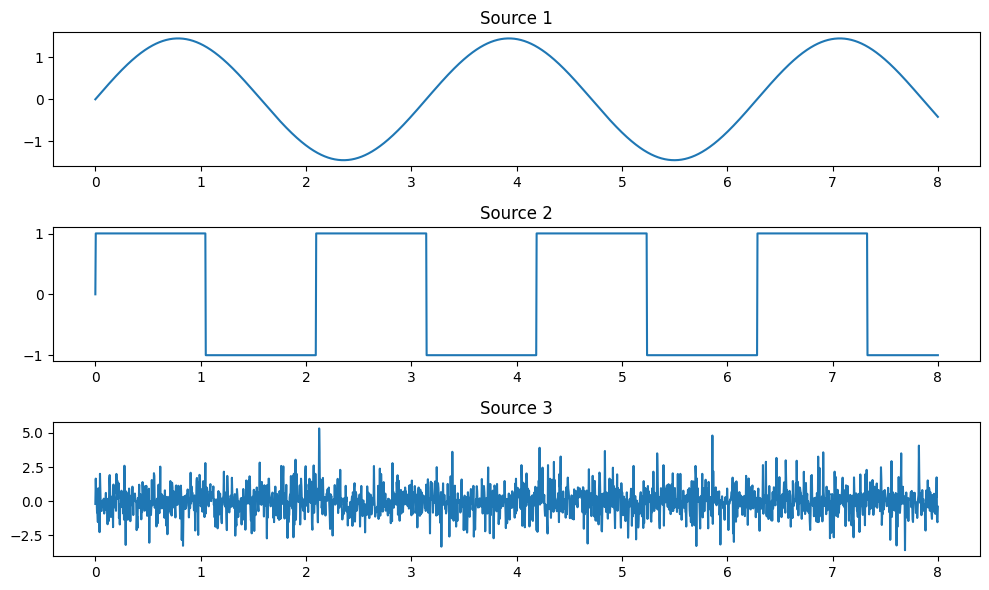

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

np.random.seed(42)

# Time axis
n_samples = 2000
time = np.linspace(0, 8, n_samples)

# Generate 3 independent, non-Gaussian source signals
s1 = np.sin(2 * time)                    # sine wave
s2 = np.sign(np.sin(3 * time))           # square wave
s3 = np.random.laplace(size=n_samples)   # random noise-like signal (non-Gaussian)

S = np.c_[s1, s2, s3]
S /= S.std(axis=0)  # normalize

fig, axes = plt.subplots(3, 1, figsize=(10, 6))
for i, ax in enumerate(axes):
    ax.plot(time, S[:, i])
    ax.set_title(f"Source {i+1}")
plt.tight_layout()
plt.show()

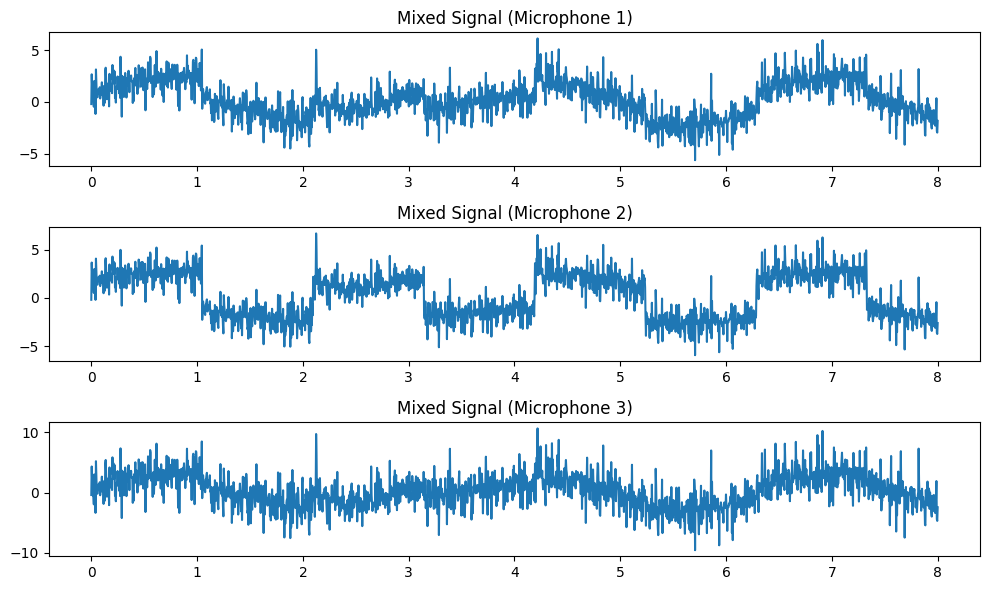

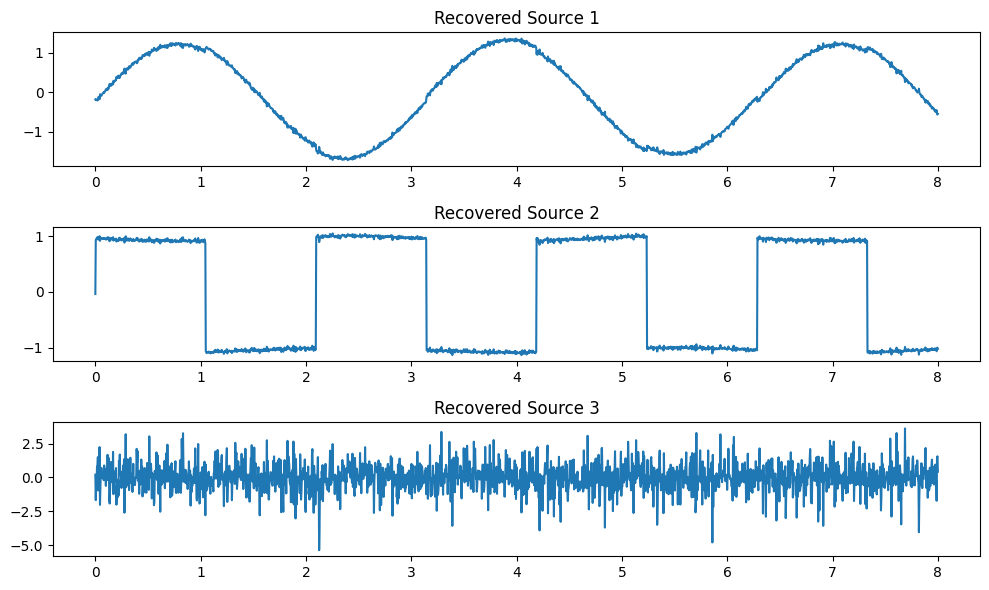

In [3]:
# Mixing matrix: each row is how a "microphone" combines the sources
A = np.array([
    [1.0, 1.0, 1.0],
    [0.5, 2.0, 1.0],
    [1.5, 1.0, 2.0]
])

X = S @ A.T  # mixed signals (what the "microphones" observe)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))
for i, ax in enumerate(axes):
    ax.plot(time, X[:, i])
    ax.set_title(f"Mixed Signal (Microphone {i+1})")
plt.tight_layout()
plt.show()

# Apply FastICA to un-mix
ica = FastICA(n_components=3, random_state=42)
S_recovered = ica.fit_transform(X)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))
for i, ax in enumerate(axes):
    ax.plot(time, S_recovered[:, i])
    ax.set_title(f"Recovered Source {i+1}")
plt.tight_layout()
plt.show()

In [5]:
from scipy.stats import pearsonr

def best_match_correlation(S_true, S_recovered):
    """For each true source, find the best-matching recovered component (since ICA order/sign is arbitrary)."""
    n = S_true.shape[1]
    results = []
    for i in range(n):
        best_corr = 0
        for j in range(n):
            corr = abs(pearsonr(S_true[:, i], S_recovered[:, j])[0])
            best_corr = max(best_corr, corr)
        results.append(best_corr)
    return results

corrs_3source = best_match_correlation(S, S_recovered)
print("3-source separation — correlation with best-matching recovered component:")
for i, c in enumerate(corrs_3source):
    print(f"Source {i+1}: {c:.4f}")
    

3-source separation — correlation with best-matching recovered component:
Source 1: 0.9981
Source 2: 0.9994
Source 3: 0.9996


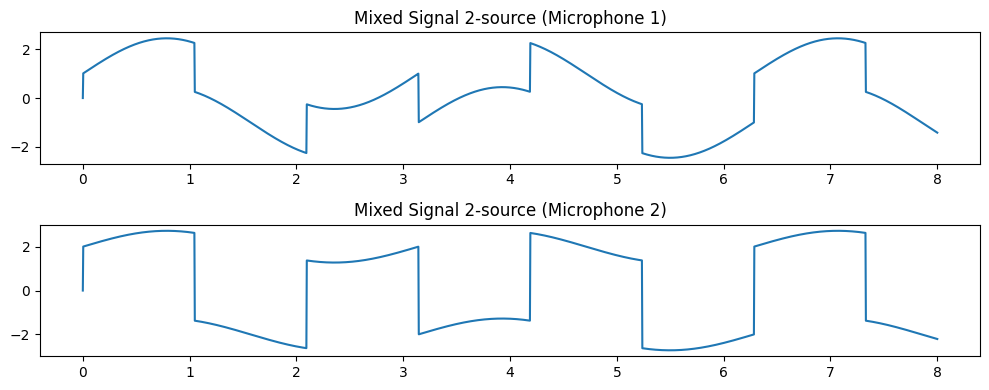

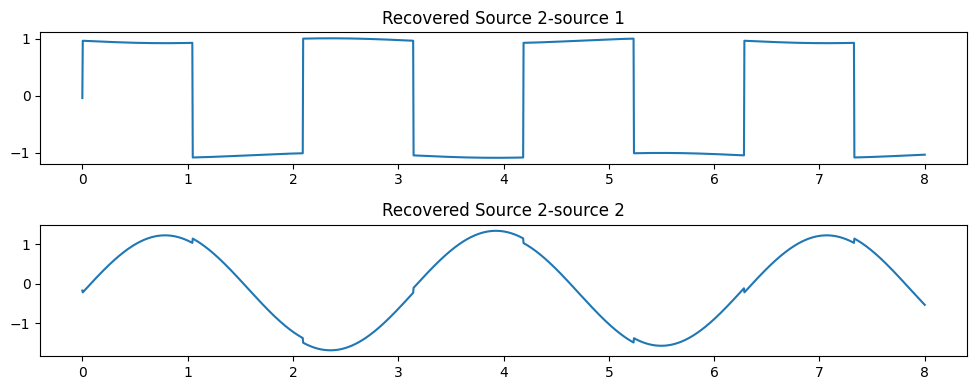

2-source separation — correlation with best-matching recovered component:
Source 1: 0.9984
Source 2: 0.9996


In [6]:
# 2-source version
S2 = S[:, :2]  # use just the first two sources (sine + square wave)

A2 = np.array([
    [1.0, 1.0],
    [0.5, 2.0]
])

X2 = S2 @ A2.T

fig, axes = plt.subplots(2, 1, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.plot(time, X2[:, i])
    ax.set_title(f"Mixed Signal 2-source (Microphone {i+1})")
plt.tight_layout()
plt.show()

ica2 = FastICA(n_components=2, random_state=42)
S2_recovered = ica2.fit_transform(X2)

fig, axes = plt.subplots(2, 1, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.plot(time, S2_recovered[:, i])
    ax.set_title(f"Recovered Source 2-source {i+1}")
plt.tight_layout()
plt.show()

corrs_2source = best_match_correlation(S2, S2_recovered)
print("2-source separation — correlation with best-matching recovered component:")
for i, c in enumerate(corrs_2source):
    print(f"Source {i+1}: {c:.4f}")

In [7]:
# Test 1: Violate the "at most one Gaussian source" constraint
gaussian_source1 = np.random.randn(2000)
gaussian_source2 = np.random.randn(2000)

S_two_gaussian = np.c_[s1, gaussian_source1, gaussian_source2]  # sine + 2 Gaussian sources
S_two_gaussian /= S_two_gaussian.std(axis=0)

A_test = np.array([
    [1.0, 1.0, 1.0],
    [0.5, 2.0, 1.0],
    [1.5, 1.0, 2.0]
])
X_two_gaussian = S_two_gaussian @ A_test.T

ica_test = FastICA(n_components=3, random_state=42)
S_recovered_test = ica_test.fit_transform(X_two_gaussian)

corrs_violation = best_match_correlation(S_two_gaussian, S_recovered_test)
print("Two-Gaussian-source violation test — correlation with best-matching component:")
print(f"Sine (non-Gaussian): {corrs_violation[0]:.4f}")
print(f"Gaussian source 1: {corrs_violation[1]:.4f}")
print(f"Gaussian source 2: {corrs_violation[2]:.4f}")

# Test 2: Noise robustness sweep
print("\nNoise robustness sweep (original 3-source mixture):")
for noise_std in [0.0, 0.1, 0.3, 0.5]:
    noisy_mixture = X + np.random.randn(*X.shape) * noise_std
    ica_noise = FastICA(n_components=3, random_state=42)
    S_recovered_noise = ica_noise.fit_transform(noisy_mixture)
    corrs_noise = best_match_correlation(S, S_recovered_noise)
    print(f"Noise std={noise_std}: mean correlation={np.mean(corrs_noise):.4f} (per-source: {[f'{c:.3f}' for c in corrs_noise]})")

Two-Gaussian-source violation test — correlation with best-matching component:
Sine (non-Gaussian): 0.9997
Gaussian source 1: 0.8576
Gaussian source 2: 0.8616

Noise robustness sweep (original 3-source mixture):
Noise std=0.0: mean correlation=0.9990 (per-source: ['0.998', '0.999', '1.000'])
Noise std=0.1: mean correlation=0.9699 (per-source: ['0.952', '0.996', '0.962'])
Noise std=0.3: mean correlation=0.8554 (per-source: ['0.785', '0.976', '0.805'])
Noise std=0.5: mean correlation=0.7731 (per-source: ['0.636', '0.940', '0.743'])
